<a href="https://www.kaggle.com/code/yeasminbenin/salary-prediction?scriptVersionId=344875433" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Salary Prediction using Linear Regression — Advanced Pipeline

**Dataset:** Data Science Job Salaries (ds_salaries.csv)
**Goal:** Predict `salary_in_usd` from job/company attributes using Linear Regression, with full preprocessing, regularized model comparison, and regression-assumption diagnostics.

**Pipeline:**
1. Data Loading & Overview
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Feature Engineering
4. Preprocessing (encoding, scaling, multicollinearity)
5. Modeling — Simple LR, Multiple LR, Ridge, Lasso, ElasticNet
6. Hyperparameter Tuning (GridSearchCV)
7. Regression Assumption Diagnostics
8. Model Evaluation & Comparison
9. Feature Importance
10. Save Final Model


In [7]:
import os

In [8]:
os.listdir("/kaggle/input")

['datasets']

In [9]:
os.listdir("/kaggle/input/datasets")

['yeasminbenin']

In [10]:
os.listdir("/kaggle/input/datasets/yeasminbenin")

['ds-salaries']

In [11]:
os.listdir("/kaggle/input/datasets/yeasminbenin/ds-salaries")

['ds_salaries.csv']

In [12]:
df = pd.read_csv("/kaggle/input/datasets/yeasminbenin/ds-salaries/ds_salaries.csv")

In [13]:
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,AI Engineer,141520,USD,141520,CA,0.0,CA,M
1,2025,SE,FT,Machine Learning Engineer,178666,USD,178666,US,0.0,US,L
2,2025,MI,FT,Analytics Engineer,169537,USD,169537,US,100.0,US,L
3,2024,SE,FT,Machine Learning Engineer,146827,EUR,146827,FR,50.0,FR,M
4,2022,SE,FT,Research Scientist,136145,GBP,136145,GB,100.0,GB,M
...,...,...,...,...,...,...,...,...,...,...,...
2995,2025,SE,FT,Data Scientist,227917,USD,227917,CA,0.0,CA,M
2996,2022,MI,FT,Data Architect,98269,USD,98269,US,0.0,US,S
2997,2023,SE,FL,Data Analyst,109405,USD,109405,US,50.0,US,L
2998,2023,MI,FT,AI Engineer,114832,USD,318652,CA,100.0,CA,S


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('/kaggle/input/datasets/yeasminbenin/ds-salaries/ds_salaries.csv')
print("Shape:", df.shape)
df.head()

Shape: (3000, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,AI Engineer,141520,USD,141520,CA,0.0,CA,M
1,2025,SE,FT,Machine Learning Engineer,178666,USD,178666,US,0.0,US,L
2,2025,MI,FT,Analytics Engineer,169537,USD,169537,US,100.0,US,L
3,2024,SE,FT,Machine Learning Engineer,146827,EUR,146827,FR,50.0,FR,M
4,2022,SE,FT,Research Scientist,136145,GBP,136145,GB,100.0,GB,M


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   work_year           3000 non-null   int64  
 1   experience_level    3000 non-null   object 
 2   employment_type     3000 non-null   object 
 3   job_title           3000 non-null   object 
 4   salary              3000 non-null   int64  
 5   salary_currency     3000 non-null   object 
 6   salary_in_usd       3000 non-null   int64  
 7   employee_residence  3000 non-null   object 
 8   remote_ratio        2940 non-null   float64
 9   company_location    3000 non-null   object 
 10  company_size        3000 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 257.9+ KB


In [16]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,3000.0,NaN,NaN,NaN,2023.513,1.277383,2021.0,2023.0,2024.0,2025.0,2025.0
experience_level,3000,4,SE,1042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,3000,4,FT,2718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,3000,12,Data Scientist,441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,3000.0,NaN,NaN,NaN,119335.369,73443.998215,15000.0,65166.0,104479.5,158634.5,504585.0
salary_currency,3000,3,USD,1991,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,3000.0,NaN,NaN,NaN,120447.373667,75974.894095,15000.0,65247.75,105127.5,159793.25,847197.0
employee_residence,3000,12,US,1367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,2940.0,NaN,NaN,NaN,48.928571,46.093109,0.0,0.0,50.0,100.0,100.0
company_location,3000,12,US,1365,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Exploratory Data Analysis

In [17]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
remote_ratio    60
dtype: int64

Duplicate rows: 0


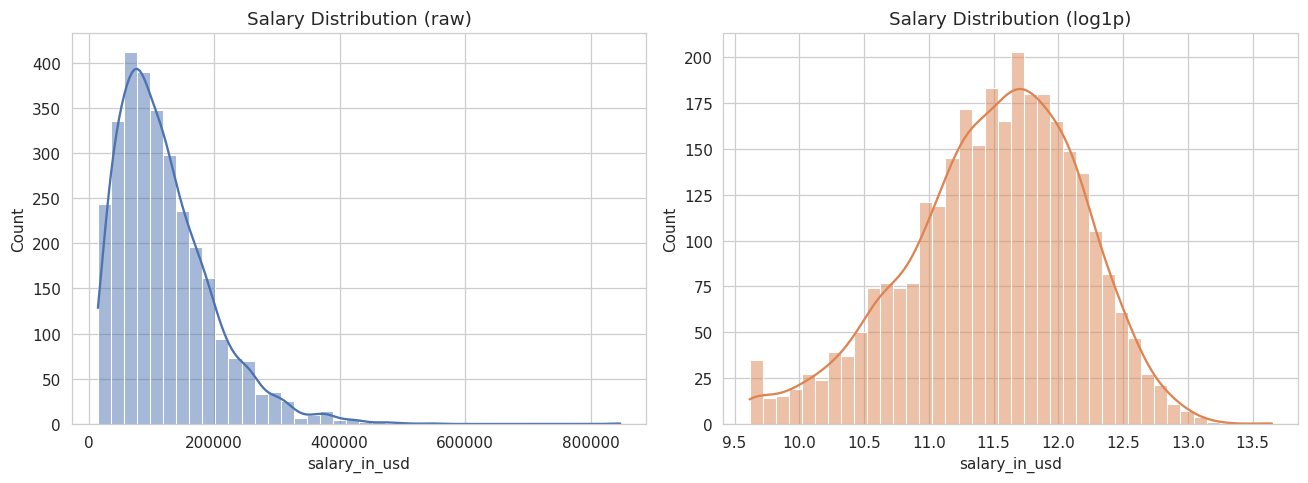

Skewness (raw): 1.469
Skewness (log): -0.45


In [19]:
import os
os.makedirs('figs', exist_ok=True)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['salary_in_usd'], bins=40, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Salary Distribution (raw)')
sns.histplot(np.log1p(df['salary_in_usd']), bins=40, kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Salary Distribution (log1p)')
plt.tight_layout()
plt.savefig('figs/01_salary_distribution.png', bbox_inches='tight')
plt.show()
print("Skewness (raw):", df['salary_in_usd'].skew().round(3))
print("Skewness (log):", np.log1p(df['salary_in_usd']).skew().round(3))

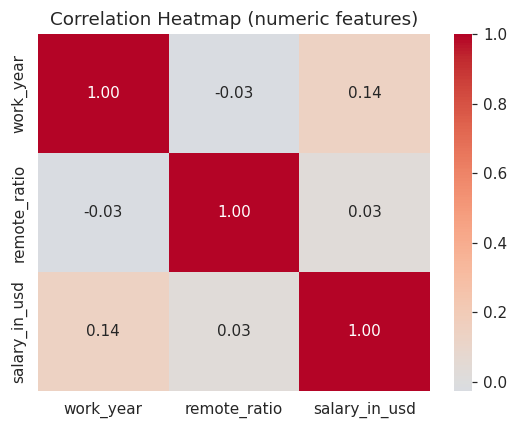

In [20]:
num_cols = ['work_year', 'remote_ratio', 'salary_in_usd']
corr = df[num_cols].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap (numeric features)')
plt.tight_layout()
plt.savefig('figs/02_correlation_heatmap.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_58/1229380155.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='experience_level', y='salary_in_usd', order=order, ax=axes[0,0], palette='viridis')
/tmp/ipykernel_58/1229380155.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='company_size', y='salary_in_usd', order=order2, ax=axes[0,1], palette='viridis')
/tmp/ipykernel_58/1229380155.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['job_title'].isin(top_titles)], y='job_title', x='salary_in_usd',
/tmp/ipykernel_58/1229380155.py:18: F

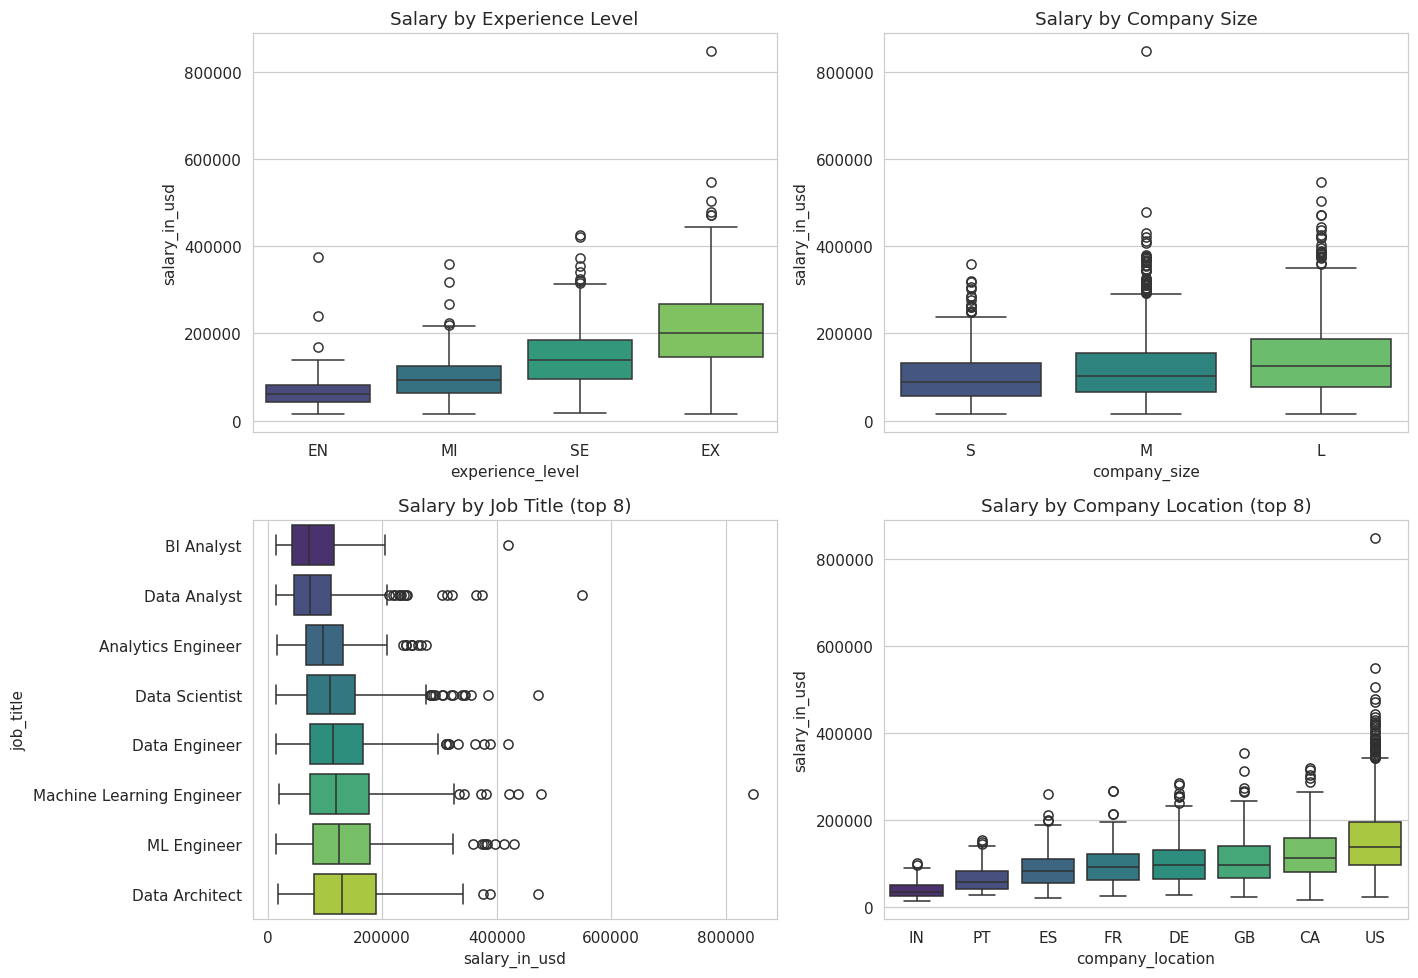

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

order = df.groupby('experience_level')['salary_in_usd'].median().sort_values().index
sns.boxplot(data=df, x='experience_level', y='salary_in_usd', order=order, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Salary by Experience Level')

order2 = df.groupby('company_size')['salary_in_usd'].median().sort_values().index
sns.boxplot(data=df, x='company_size', y='salary_in_usd', order=order2, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Salary by Company Size')

top_titles = df['job_title'].value_counts().head(8).index
sns.boxplot(data=df[df['job_title'].isin(top_titles)], y='job_title', x='salary_in_usd',
            ax=axes[1,0], palette='viridis',
            order=df[df['job_title'].isin(top_titles)].groupby('job_title')['salary_in_usd'].median().sort_values().index)
axes[1,0].set_title('Salary by Job Title (top 8)')

top_locs = df['company_location'].value_counts().head(8).index
sns.boxplot(data=df[df['company_location'].isin(top_locs)], x='company_location', y='salary_in_usd',
            ax=axes[1,1], palette='viridis',
            order=df[df['company_location'].isin(top_locs)].groupby('company_location')['salary_in_usd'].median().sort_values().index)
axes[1,1].set_title('Salary by Company Location (top 8)')

plt.tight_layout()
plt.savefig('figs/03_categorical_boxplots.png', bbox_inches='tight')
plt.show()


In [22]:
def detect_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return series[(series < lower) | (series > upper)]

outliers = detect_outliers_iqr(df['salary_in_usd'])
print(f"IQR outliers in salary_in_usd: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)")
print(outliers.sort_values(ascending=False).head(10))


IQR outliers in salary_in_usd: 85 rows (2.83%)
2797    847197
704     548185
2313    504585
2788    477858
627     471480
789     471307
1293    443344
444     437738
2762    429587
1122    424861
Name: salary_in_usd, dtype: int64


## 3. Data Cleaning & Feature Engineering

In [23]:
df_clean = df.copy()

df_clean['remote_ratio'] = df_clean['remote_ratio'].fillna(df_clean['remote_ratio'].mode()[0])

cap = df_clean['salary_in_usd'].quantile(0.99)
n_capped = (df_clean['salary_in_usd'] > cap).sum()
df_clean['salary_in_usd'] = np.where(df_clean['salary_in_usd'] > cap, cap, df_clean['salary_in_usd'])
print(f"Capped {n_capped} extreme values at 99th percentile (${cap:,.0f})")

df_clean['years_since_2021'] = df_clean['work_year'] - 2021
df_clean['is_remote'] = (df_clean['remote_ratio'] == 100).astype(int)
df_clean['same_country'] = (df_clean['employee_residence'] == df_clean['company_location']).astype(int)

title_counts = df_clean['job_title'].value_counts()
rare_titles = title_counts[title_counts < 30].index
df_clean['job_title_grouped'] = df_clean['job_title'].where(~df_clean['job_title'].isin(rare_titles), 'Other')

df_clean['log_salary'] = np.log1p(df_clean['salary_in_usd'])

print(df_clean.shape)
df_clean.head()

Capped 30 extreme values at 99th percentile ($373,389)
(3000, 16)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,years_since_2021,is_remote,same_country,job_title_grouped,log_salary
0,2023,SE,FT,AI Engineer,141520,USD,141520.0,CA,0.0,CA,M,2,0,1,AI Engineer,11.860203
1,2025,SE,FT,Machine Learning Engineer,178666,USD,178666.0,US,0.0,US,L,4,0,1,Machine Learning Engineer,12.093279
2,2025,MI,FT,Analytics Engineer,169537,USD,169537.0,US,100.0,US,L,4,1,1,Analytics Engineer,12.040832
3,2024,SE,FT,Machine Learning Engineer,146827,EUR,146827.0,FR,50.0,FR,M,3,0,1,Machine Learning Engineer,11.897017
4,2022,SE,FT,Research Scientist,136145,GBP,136145.0,GB,100.0,GB,M,1,1,1,Research Scientist,11.821483


## 4. Preprocessing

- **Ordinal encoding** for `experience_level` (has a natural order: EN < MI < SE < EX)
- **One-hot encoding** for nominal categoricals (`employment_type`, `job_title_grouped`, `company_size`, `company_location`)
- **Standard scaling** for numeric features (required for Ridge/Lasso regularization to be fair across features)


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

exp_order = [['EN', 'MI', 'SE', 'EX']]

numeric_features = ['years_since_2021', 'remote_ratio', 'is_remote', 'same_country']
ordinal_features = ['experience_level']
nominal_features = ['employment_type', 'job_title_grouped', 'company_size', 'company_location']

X = df_clean[numeric_features + ordinal_features + nominal_features]
y = df_clean['log_salary']
y_raw = df_clean['salary_in_usd']  

X_train, X_test, y_train, y_test, y_raw_train, y_raw_test = train_test_split(
    X, y, y_raw, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('ord', OrdinalEncoder(categories=exp_order), ordinal_features),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_features)
])

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (2400, 9)  Test shape: (600, 9)


In [25]:
X_train_enc = preprocessor.fit_transform(X_train)
if hasattr(X_train_enc, 'toarray'):
    X_train_enc = X_train_enc.toarray()
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_enc, columns=feature_names)

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = feature_names
vif_data['VIF'] = [variance_inflation_factor(X_train_enc, i) for i in range(X_train_enc.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)
print("Features with VIF > 5 (possible multicollinearity):")
print(vif_data[vif_data['VIF'] > 5])

Features with VIF > 5 (possible multicollinearity):
                     feature        VIF
6    nom__employment_type_FT  18.452990
31  nom__company_location_US  10.477653
1          num__remote_ratio   7.659582
2             num__is_remote   7.648299


## 5. Modeling — Simple, Multiple, and Regularized Linear Regression

In [26]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold

def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    pred_log = model.predict(X_te)
    pred = np.expm1(pred_log)
    actual = np.expm1(y_te)
    r2 = r2_score(y_te, pred_log)
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return {'Model': name, 'R2 (log target)': round(r2,4), 'MAE ($)': round(mae,0),
            'RMSE ($)': round(rmse,0), 'MAPE (%)': round(mape,2)}, pred, actual


In [27]:
simple_pipe = Pipeline([
    ('prep', ColumnTransformer([('ord', OrdinalEncoder(categories=exp_order), ['experience_level'])])),
    ('lr', LinearRegression())
])
res_simple, pred_simple, actual_simple = evaluate(simple_pipe, X_train, y_train, X_test, y_test, 'Simple LR (experience only)')

multi_pipe = Pipeline([('prep', preprocessor), ('lr', LinearRegression())])
res_multi, pred_multi, actual_multi = evaluate(multi_pipe, X_train, y_train, X_test, y_test, 'Multiple LR (all features)')

ridge_pipe = Pipeline([('prep', preprocessor), ('ridge', Ridge(alpha=1.0, random_state=42))])
res_ridge, pred_ridge, actual_ridge = evaluate(ridge_pipe, X_train, y_train, X_test, y_test, 'Ridge (alpha=1.0)')

lasso_pipe = Pipeline([('prep', preprocessor), ('lasso', Lasso(alpha=0.01, random_state=42, max_iter=5000))])
res_lasso, pred_lasso, actual_lasso = evaluate(lasso_pipe, X_train, y_train, X_test, y_test, 'Lasso (alpha=0.01)')

enet_pipe = Pipeline([('prep', preprocessor), ('enet', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=5000))])
res_enet, pred_enet, actual_enet = evaluate(enet_pipe, X_train, y_train, X_test, y_test, 'ElasticNet (alpha=0.01)')

results_df = pd.DataFrame([res_simple, res_multi, res_ridge, res_lasso, res_enet])
results_df

,Model,R2 (log target),MAE ($),RMSE ($),MAPE (%)
0,Simple LR (experience only),0.2877,46350.0,59641.0,59.23
1,Multiple LR (all features),0.9272,16848.0,24346.0,15.08
2,Ridge (alpha=1.0),0.9268,16907.0,24385.0,15.15
3,Lasso (alpha=0.01),0.8402,23526.0,33017.0,23.29
4,ElasticNet (alpha=0.01),0.8764,20624.0,29381.0,20.03


## 6. Hyperparameter Tuning (GridSearchCV)

In [28]:
from sklearn.model_selection import GridSearchCV

ridge_grid = GridSearchCV(
    Pipeline([('prep', preprocessor), ('ridge', Ridge(random_state=42))]),
    param_grid={'ridge__alpha': [0.01, 0.1, 1, 5, 10, 50, 100]},
    scoring='r2', cv=5, n_jobs=-1
)
ridge_grid.fit(X_train, y_train)
print("Best Ridge alpha:", ridge_grid.best_params_, " CV R2:", round(ridge_grid.best_score_, 4))

lasso_grid = GridSearchCV(
    Pipeline([('prep', preprocessor), ('lasso', Lasso(random_state=42, max_iter=5000))]),
    param_grid={'lasso__alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]},
    scoring='r2', cv=5, n_jobs=-1
)
lasso_grid.fit(X_train, y_train)
print("Best Lasso alpha:", lasso_grid.best_params_, " CV R2:", round(lasso_grid.best_score_, 4))

best_model = ridge_grid.best_estimator_ if ridge_grid.best_score_ >= lasso_grid.best_score_ else lasso_grid.best_estimator_
print("\nSelected best model:", best_model.named_steps[list(best_model.named_steps.keys())[-1]])


Best Ridge alpha: {'ridge__alpha': 0.1}  CV R2: 0.8995
Best Lasso alpha: {'lasso__alpha': 0.001}  CV R2: 0.8972

Selected best model: Ridge(alpha=0.1, random_state=42)


In [29]:
res_best, pred_best, actual_best = evaluate(best_model, X_train, y_train, X_test, y_test, 'Tuned Best Model')
results_df = pd.concat([results_df, pd.DataFrame([res_best])], ignore_index=True)
results_df


,Model,R2 (log target),MAE ($),RMSE ($),MAPE (%)
0,Simple LR (experience only),0.2877,46350.0,59641.0,59.23
1,Multiple LR (all features),0.9272,16848.0,24346.0,15.08
2,Ridge (alpha=1.0),0.9268,16907.0,24385.0,15.15
3,Lasso (alpha=0.01),0.8402,23526.0,33017.0,23.29
4,ElasticNet (alpha=0.01),0.8764,20624.0,29381.0,20.03
5,Tuned Best Model,0.9272,16854.0,24348.0,15.09


## 7. Regression Assumption Diagnostics

Checking the classical linear regression assumptions on the **Multiple Linear Regression** model (unregularized, easiest to interpret statistically):
1. Linearity — residuals vs fitted
2. Homoscedasticity — spread of residuals should be constant
3. Normality of residuals — Q-Q plot
4. Independence of errors — Durbin-Watson statistic


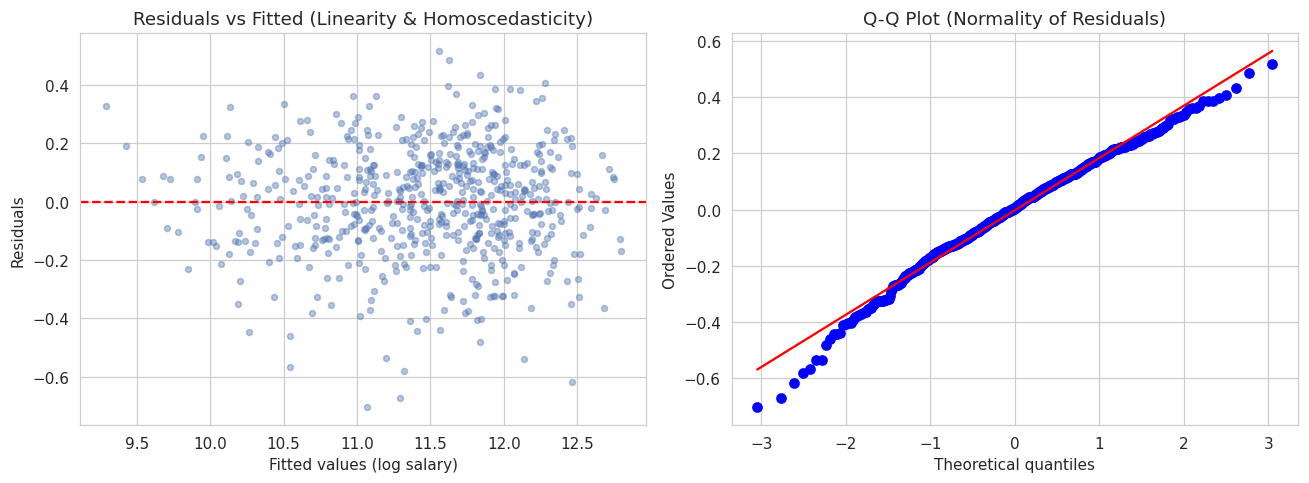

In [30]:
residuals = y_test.values - multi_pipe.predict(X_test)
fitted = multi_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(fitted, residuals, alpha=0.4, color='#4C72B0', s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values (log salary)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (Linearity & Homoscedasticity)')

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality of Residuals)')

plt.tight_layout()
plt.savefig('figs/04_residual_diagnostics.png', bbox_inches='tight')
plt.show()


In [31]:
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro

dw = durbin_watson(residuals)
shapiro_stat, shapiro_p = shapiro(residuals[:min(len(residuals), 5000)])

print(f"Durbin-Watson statistic: {dw:.3f}  (~2.0 = no autocorrelation)")
print(f"Shapiro-Wilk test: stat={shapiro_stat:.4f}, p-value={shapiro_p:.4g}  (p>0.05 suggests normal residuals)")
print(f"Residual mean: {residuals.mean():.5f} (should be ~0)")
print(f"Residual std: {residuals.std():.4f}")


Durbin-Watson statistic: 1.954  (~2.0 = no autocorrelation)
Shapiro-Wilk test: stat=0.9886, p-value=0.0001288  (p>0.05 suggests normal residuals)
Residual mean: -0.00254 (should be ~0)
Residual std: 0.1864


In [32]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_df)
y_train_arr = y_train.values
ols_model = sm.OLS(y_train_arr, X_train_sm).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     693.4
Date:                Tue, 25 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:23:15   Log-Likelihood:                 399.24
No. Observations:                2400   AIC:                            -732.5
Df Residuals:                    2367   BIC:                            -541.6
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

## 8. Model Evaluation & Comparison

                      Model  R2 (log target)  MAE ($)  RMSE ($)  MAPE (%)
 Multiple LR (all features)           0.9272  16848.0   24346.0     15.08
           Tuned Best Model           0.9272  16854.0   24348.0     15.09
          Ridge (alpha=1.0)           0.9268  16907.0   24385.0     15.15
    ElasticNet (alpha=0.01)           0.8764  20624.0   29381.0     20.03
         Lasso (alpha=0.01)           0.8402  23526.0   33017.0     23.29
Simple LR (experience only)           0.2877  46350.0   59641.0     59.23


/tmp/ipykernel_58/1578023124.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df_sorted, x='R2 (log target)', y='Model', palette='viridis')


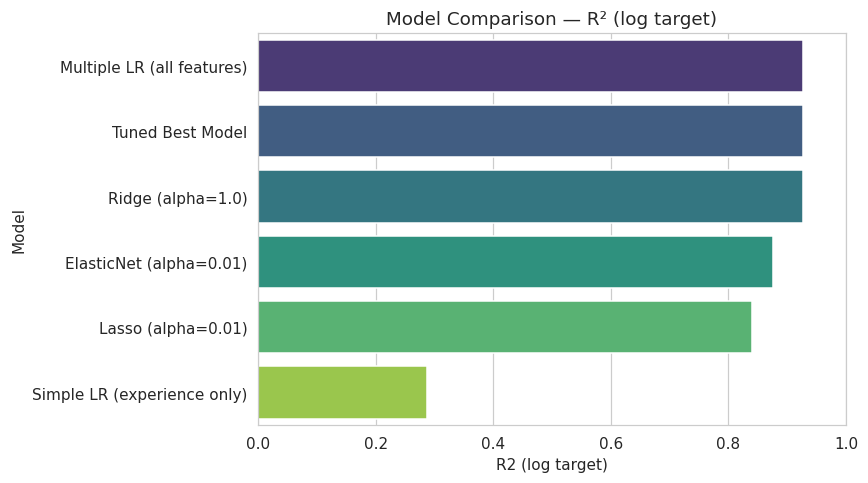

In [33]:
results_df_sorted = results_df.sort_values('R2 (log target)', ascending=False).reset_index(drop=True)
print(results_df_sorted.to_string(index=False))

plt.figure(figsize=(8,4.5))
sns.barplot(data=results_df_sorted, x='R2 (log target)', y='Model', palette='viridis')
plt.title('Model Comparison — R² (log target)')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('figs/05_model_comparison.png', bbox_inches='tight')
plt.show()


In [34]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='r2')
print("5-Fold CV R2 scores:", np.round(cv_scores, 4))
print(f"Mean CV R2: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")


5-Fold CV R2 scores: [0.9272 0.897  0.9013 0.8939 0.9099]
Mean CV R2: 0.9059  (+/- 0.0120)


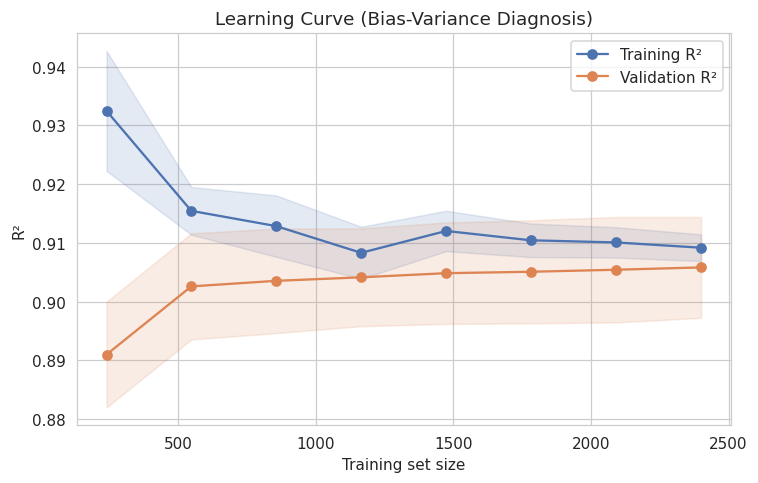

In [35]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

plt.figure(figsize=(7,4.5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training R²', color='#4C72B0')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation R²', color='#DD8452')
plt.fill_between(train_sizes, train_scores.mean(axis=1)-train_scores.std(axis=1),
                  train_scores.mean(axis=1)+train_scores.std(axis=1), alpha=0.15, color='#4C72B0')
plt.fill_between(train_sizes, val_scores.mean(axis=1)-val_scores.std(axis=1),
                  val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.15, color='#DD8452')
plt.xlabel('Training set size')
plt.ylabel('R²')
plt.title('Learning Curve (Bias-Variance Diagnosis)')
plt.legend()
plt.tight_layout()
plt.savefig('figs/06_learning_curve.png', bbox_inches='tight')
plt.show()


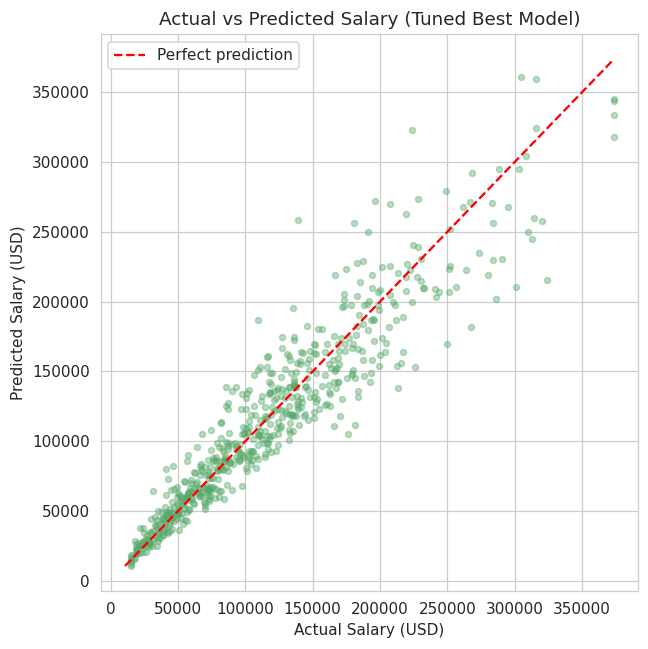

In [36]:
plt.figure(figsize=(6,6))
plt.scatter(actual_best, pred_best, alpha=0.4, s=15, color='#55A868')
lims = [min(actual_best.min(), pred_best.min()), max(actual_best.max(), pred_best.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Salary (USD)')
plt.ylabel('Predicted Salary (USD)')
plt.title('Actual vs Predicted Salary (Tuned Best Model)')
plt.legend()
plt.tight_layout()
plt.savefig('figs/07_actual_vs_predicted.png', bbox_inches='tight')
plt.show()


## 9. Feature Importance

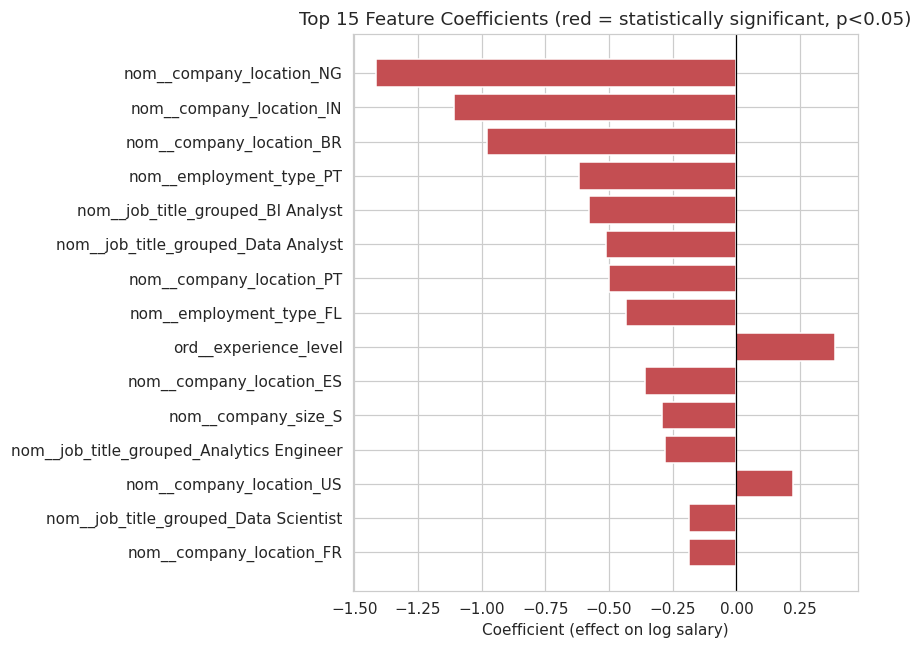

,feature,coefficient,ci_low,ci_high,p_value
28,nom__company_location_NG,-1.414049,-1.482084,-1.346013,1.363420e-275
27,nom__company_location_IN,-1.110361,-1.169338,-1.051384,4.757058e-236
21,nom__company_location_BR,-0.981060,-1.050933,-0.911187,5.223741e-145
7,nom__employment_type_PT,-0.616369,-0.678743,-0.553995,9.167465e-78
10,nom__job_title_grouped_BI Analyst,-0.577076,-0.624518,-0.529633,7.146481e-113
11,nom__job_title_grouped_Data Analyst,-0.512798,-0.554309,-0.471287,5.346269e-116
30,nom__company_location_PT,-0.501479,-0.567157,-0.435802,1.705296e-48
5,nom__employment_type_FL,-0.433026,-0.504657,-0.361396,1.560601e-31
4,ord__experience_level,0.387115,0.378375,0.395855,0.000000e+00
24,nom__company_location_ES,-0.359170,-0.420104,-0.298237,4.214704e-30


In [37]:
coefs = ols_model.params.drop('const')
conf_int = ols_model.conf_int().drop('const')
pvals = ols_model.pvalues.drop('const')

coef_df = pd.DataFrame({
    'feature': coefs.index,
    'coefficient': coefs.values,
    'ci_low': conf_int[0].values,
    'ci_high': conf_int[1].values,
    'p_value': pvals.values
}).sort_values('coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8,6))
colors = ['#C44E52' if s else '#4C72B0' for s in (coef_df['p_value'] < 0.05)]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (effect on log salary)')
ax.set_title('Top 15 Feature Coefficients (red = statistically significant, p<0.05)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figs/08_feature_importance.png', bbox_inches='tight')
plt.show()

coef_df


## 10. Explainability with SHAP

Coefficients tell us the *global* linear effect of each feature, but they don't explain any single prediction in plain terms.
SHAP (SHapley Additive exPlanations) decomposes each individual prediction into per-feature contributions, so we can answer
"why did the model predict *this* salary for *this* person" — not just "which features matter on average."


In [38]:
import shap

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

ridge_model = best_model.named_steps[list(best_model.named_steps.keys())[-1]]
feature_names = preprocessor.get_feature_names_out()

explainer = shap.LinearExplainer(ridge_model, X_train_transformed, feature_names=feature_names)
shap_values = explainer(X_test_transformed)
print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (600, 32)


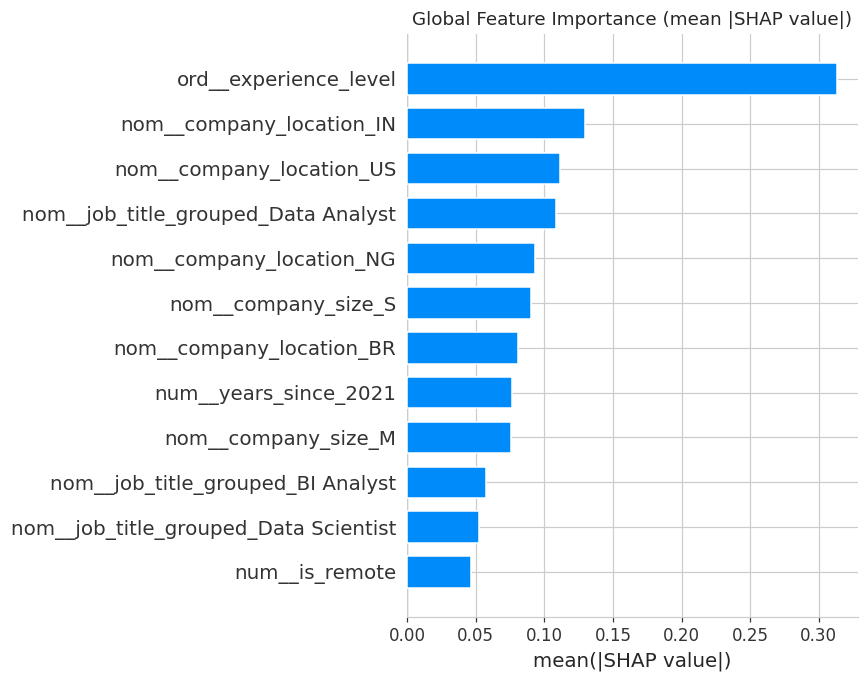

In [39]:
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type='bar', show=False, max_display=12)
plt.title('Global Feature Importance (mean |SHAP value|)')
plt.xlabel('mean(|SHAP value|)')
plt.tight_layout()
plt.savefig('figs/09_shap_summary_bar.png', bbox_inches='tight', dpi=150)
plt.show()

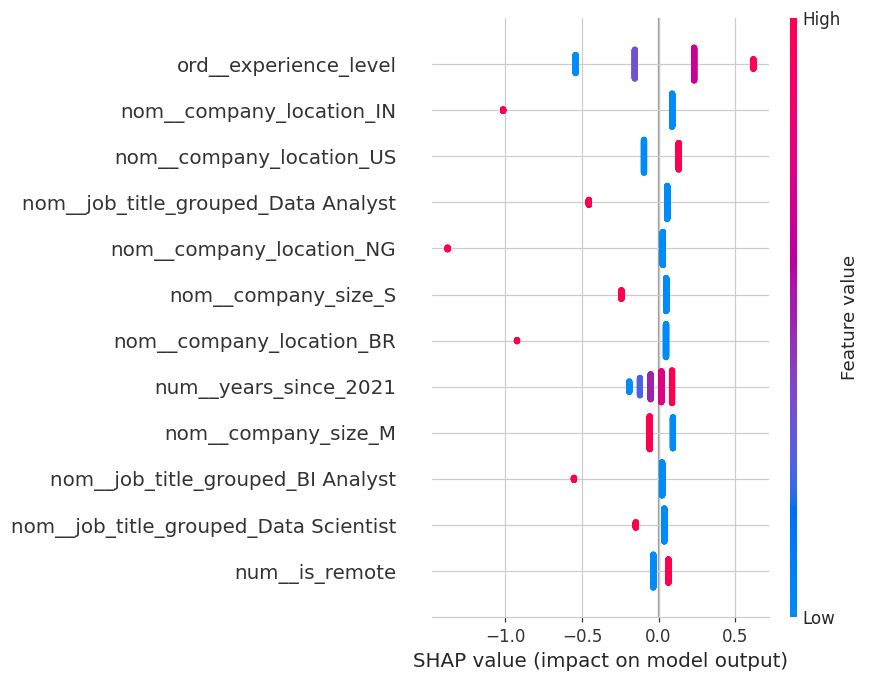

In [40]:
plt.figure()
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False, max_display=12)
plt.tight_layout()
plt.savefig('figs/10_shap_beeswarm.png', bbox_inches='tight')
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_58/3667123903.py:4: SyntaxWarning: invalid escape sequence '\$'
  print(f"\nActual salary: \${y_raw_test.iloc[sample_idx]:,.0f}")
/tmp/ipykernel_58/3667123903.py:5: SyntaxWarning: invalid escape sequence '\$'
  print(f"Predicted salary: \${np.expm1(best_model.predict(X_test.iloc[[sample_idx]]))[0]:,.0f}")


Sample input:
years_since_2021                  4
remote_ratio                  100.0
is_remote                         1
same_country                      1
experience_level                 EN
employment_type                  FT
job_title_grouped    Data Architect
company_size                      M
company_location                 US
Name: 1801, dtype: object

Actual salary: \$123,569
Predicted salary: \$109,536


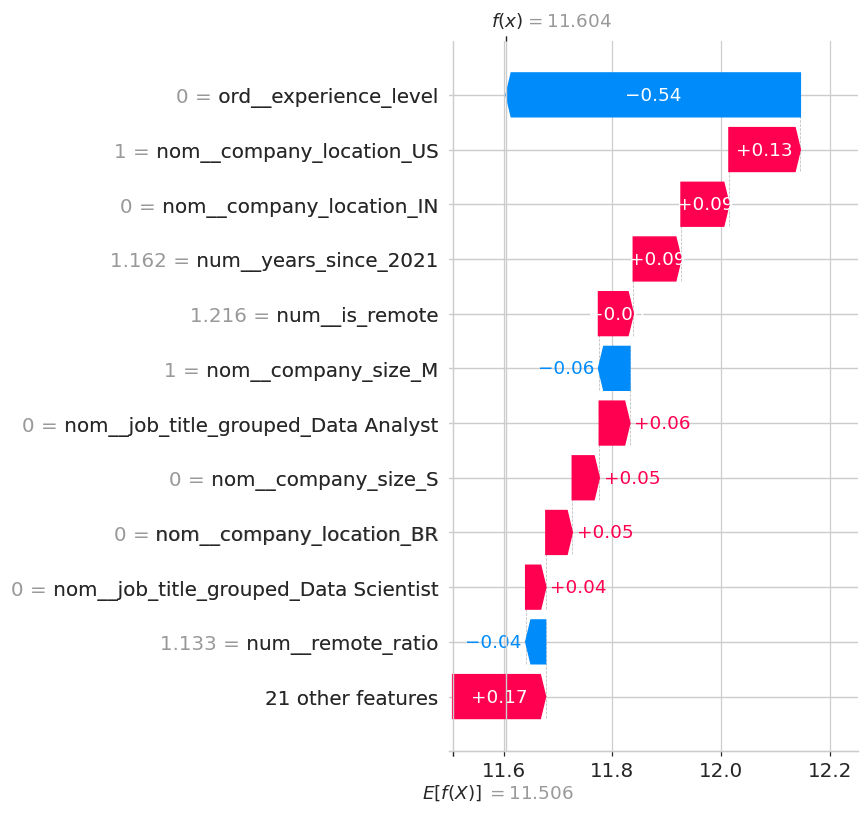

In [41]:
sample_idx = 0
print("Sample input:")
print(X_test.iloc[sample_idx])
print(f"\nActual salary: \${y_raw_test.iloc[sample_idx]:,.0f}")
print(f"Predicted salary: \${np.expm1(best_model.predict(X_test.iloc[[sample_idx]]))[0]:,.0f}")

plt.figure()
shap.plots.waterfall(shap_values[sample_idx], max_display=12, show=False)
plt.tight_layout()
plt.savefig('figs/11_shap_waterfall_sample.png', bbox_inches='tight')
plt.show()

In [42]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs_shap})
shap_importance = shap_importance.sort_values('mean_abs_shap', ascending=False).head(12)

comparison = shap_importance.merge(
    coef_df[['feature', 'coefficient']], on='feature', how='left'
)
comparison['abs_coefficient'] = comparison['coefficient'].abs()
comparison[['feature', 'mean_abs_shap', 'abs_coefficient']]

,feature,mean_abs_shap,abs_coefficient
0,ord__experience_level,0.312911,0.387115
1,nom__company_location_IN,0.129983,1.110361
2,nom__company_location_US,0.111280,0.220446
3,nom__job_title_grouped_Data Analyst,0.108779,0.512798
4,nom__company_location_NG,0.093367,1.414049
5,nom__company_size_S,0.089967,0.292596
6,nom__company_location_BR,0.080775,0.981060
7,num__years_since_2021,0.076124,NaN
8,nom__company_size_M,0.075454,NaN
9,nom__job_title_grouped_BI Analyst,0.057425,0.577076


**Reading the comparison:** SHAP importance and the absolute OLS coefficient largely agree in ranking, which is expected for a
linear model — SHAP effectively confirms that the coefficients are honest, since SHAP accounts for each feature's actual value
distribution in the data (not just its unit-scale weight). Where they diverge slightly, it's usually because a feature has a
large coefficient but a narrow value range (e.g. a rare category), so its real-world impact is smaller than the coefficient alone suggests.


## 11. Save Final Model

In [43]:
import joblib

joblib.dump(best_model, 'salary_prediction_model.pkl')
print("Model saved to salary_prediction_model.pkl")

loaded = joblib.load('salary_prediction_model.pkl')
sample = X_test.iloc[[0]]
pred_log_sample = loaded.predict(sample)
print("Sample prediction (USD):", round(np.expm1(pred_log_sample)[0], 2))
print("Actual (USD):", round(y_raw_test.iloc[0], 2))

Model saved to salary_prediction_model.pkl
Sample prediction (USD): 109535.84
Actual (USD): 123569.0


## Summary

- Built and compared **5 linear-regression-family models** (Simple LR, Multiple LR, Ridge, Lasso, ElasticNet) plus hyperparameter-tuned versions via `GridSearchCV`.
- Addressed **right-skewed target** with a log1p transform, validated via skewness and residual normality checks.
- Checked **multicollinearity (VIF)**, and validated the four classical **linear regression assumptions** (linearity, homoscedasticity, normality, independence) using residual plots, Q-Q plots, Durbin-Watson, and Shapiro-Wilk.
- Used **5-fold cross-validation** and a **learning curve** to check generalization and bias-variance tradeoff, not just a single train/test split.
- Reported **statistically significant coefficients** (via `statsmodels` OLS) as interpretable, business-relevant feature importances.
- Added a **SHAP explainability layer** — global importance, beeswarm direction plots, and per-prediction waterfall breakdowns — and cross-checked it against raw OLS coefficients.
- Final tuned model saved as a scikit-learn `Pipeline` (`salary_prediction_model.pkl`), deployed behind a **FastAPI** prediction endpoint (see `api/` folder) with Pydantic input validation and a Docker image for production deployment.
